In fact only pyts need to be installed, if code under not works, just run "!pip install pyts" in separated cell.
If you working in local repository write "pip install -r requirements.txt" to the terminal and skip this cell

In [ ]:
!pip install -r requirements.txt

  Using cached https://download.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp311-cp311-linux_x86_64.whl (768.5 MB)
  Using cached https://download.pytorch.org/whl/cu124/torchaudio-2.6.0%2Bcu124-cp311-cp311-linux_x86_64.whl (3.4 MB)
  Using cached https://download.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp311-cp311-linux_x86_64.whl (7.3 MB)


Impoting nessesary libs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from pyts.image import GramianAngularField

# Task 1

## Data loading and pre-processing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Loading CSV
df = pd.read_csv("opsd_raw.csv", parse_dates=["utc_timestamp"])

# Data info
print("Dataset size", df.shape)
print(df.head())

# Selecting only Denmark rows
df = df[[
    "utc_timestamp",
    "DK_load_actual_entsoe_transparency",
    "DK_wind_generation_actual",
    "DK_solar_generation_actual"
]]

# Short naming
df.columns = ["timestamp", "load", "wind", "solar"]

# Checking the misses
print("NUmber of misses:")
print(df.isna().sum())

# Dropping misses
df = df.dropna()

# Check
print("Size after droping the misses:", df.shape)

Dataset size (50400, 99)
              utc_timestamp  DK_load_actual_entsoe_transparency  \
0 2015-01-01 00:00:00+00:00                                 NaN   
1 2015-01-01 01:00:00+00:00                             3100.02   
2 2015-01-01 02:00:00+00:00                             2980.39   
3 2015-01-01 03:00:00+00:00                             2933.49   
4 2015-01-01 04:00:00+00:00                             2941.54   

   DK_load_forecast_entsoe_transparency  DK_solar_capacity  \
0                                   NaN              489.0   
1                                3126.8              489.0   
2                                3019.0              489.0   
3                                2976.3              489.0   
4                                2982.5              489.0   

   DK_solar_generation_actual  DK_wind_capacity  DK_wind_generation_actual  \
0                         NaN            4643.0                        NaN   
1                         NaN            46

In [ ]:
# Insure that the index related to date
df.set_index("timestamp", inplace=True)

# Resample by the hour
df = df.resample('h').mean()

# Grouping by days and dates
daily_records = []
dates = []

for date, group in df.groupby(df.index.date):
    if len(group) == 24:  # only full day
        sample = {
            'date': date,
            'load': group['load'].values,
            'wind': group['wind'].values,
            'solar': group['solar'].values
        }
        daily_records.append(sample)
        dates.append(date)

print(f"Created {len(daily_records)} full daily records.")

Сформировано 2098 полных суточных записей.


In [ ]:
# Adding seasons
def get_season(date):
    month = date.month
    day = date.day
    if (month == 12 and day >= 1) or (month in [1, 2]) or (month == 3 and day < 1):
        return 'winter'
    elif (month == 3 and day >= 1) or month in [4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'autumn'
    else:
        return 'unknown'

for rec in daily_records:
    rec['season'] = get_season(pd.to_datetime(rec['date']))

# info checking
from collections import Counter
season_counts = Counter([r['season'] for r in daily_records])
print("Distribution by seasons:")
print(season_counts)

Распределение по сезонам:
Counter({'spring': 552, 'summer': 552, 'winter': 510, 'autumn': 484})


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Refactor the data as list
X = np.array([np.stack([r['load'], r['wind'], r['solar']]) for r in daily_records])  # (N, 3, 24)

# seasons -> labels 0–3
le = LabelEncoder()
y = le.fit_transform([r['season'] for r in daily_records])  # (N,)

# Train / Validation / Test split (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)
# 0.1765 * 0.85 ≈ 0.15 (так мы получаем 70/15/15)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1468, 3, 24)
Val shape: (315, 3, 24)
Test shape: (315, 3, 24)


In [ ]:
# Scaling each feature separately
scalers = []
X_train_scaled = np.empty_like(X_train)
X_val_scaled = np.empty_like(X_val)
X_test_scaled = np.empty_like(X_test)

for i in range(3):  # 3 ауфегкуы
    scaler = StandardScaler()

    # Fit by train, transform
    train_i = X_train[:, i, :]  # (num_days, 24)
    val_i = X_val[:, i, :]
    test_i = X_test[:, i, :]

    X_train_scaled[:, i, :] = scaler.fit_transform(train_i)
    X_val_scaled[:, i, :] = scaler.transform(val_i)
    X_test_scaled[:, i, :] = scaler.transform(test_i)

    scalers.append(scaler)

## Inspecting the data

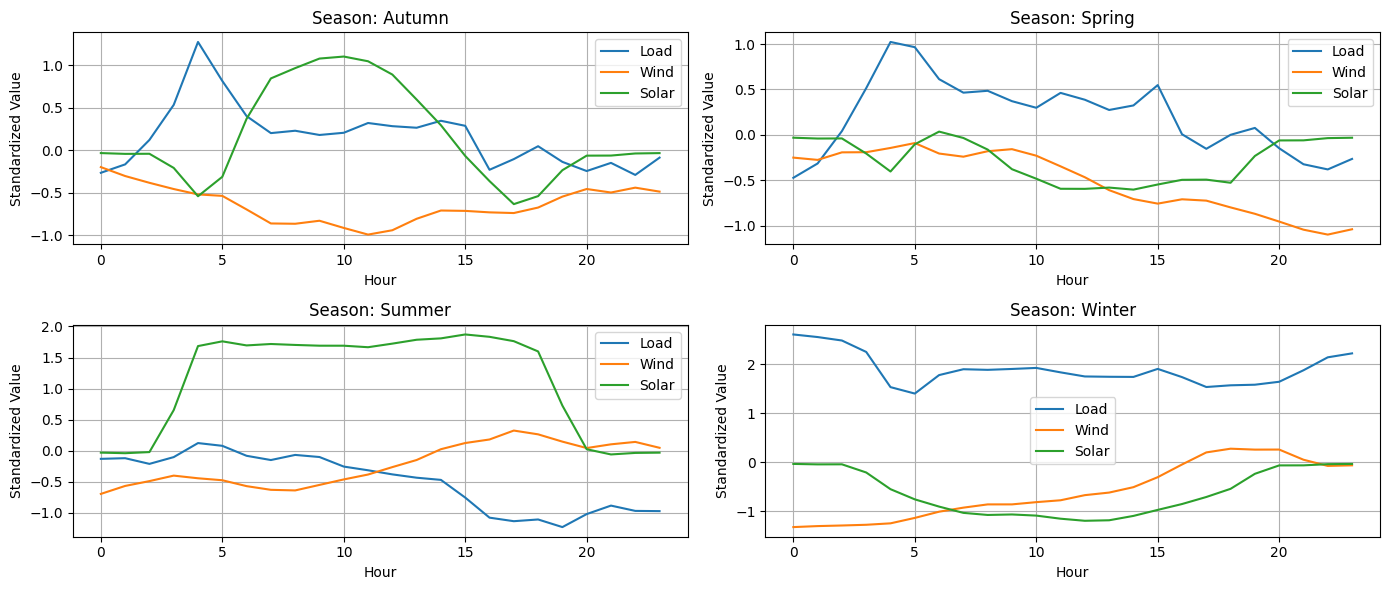

In [ ]:
import random

season_map = {i: name for i, name in enumerate(le.classes_)}  # 0 -> 'autumn', и т.д.

def plot_example_per_season(X, y, season_map, title_prefix=""):
    plt.figure(figsize=(14, 6))

    for idx, season in enumerate(sorted(set(y))):
        # random day of season
        season_indices = np.where(y == season)[0]
        i = random.choice(season_indices)
        day_data = X[i]

        plt.subplot(2, 2, idx+1)
        plt.plot(day_data[0], label='Load')
        plt.plot(day_data[1], label='Wind')
        plt.plot(day_data[2], label='Solar')
        plt.title(f"{title_prefix} {season_map[season].capitalize()}")
        plt.xlabel("Hour")
        plt.ylabel("Standardized Value")
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()

# Watching the random examples from the sample
plot_example_per_season(X_train_scaled, y_train, season_map, "Season:")

The graphs show that during the winter months the total consumption (“Load”) during the day is noticeably higher than in summer. It can also be seen that solar generation (“Solar”) is much weaker in winter, especially in the early and late hours of the day, in contrast to summer, where the solar generation curve resembles a symmetrical dome corresponding to a day with long daylight hours. Wind generation (“Wind”) behaves less regularly and has large fluctuations during the day, regardless of the season.

Summary on Task 1 - Data Preprocessing & EDA
Feature selection:

From README.md identified the right columns for Denmark:

DK_load_actual_entsoe_transparency - consumption

DK_wind_generation_actual - wind power

DK_solar_generation_actual - solar generation

Data processing:

Converted hourly values to daily arrays: 3 fixes × 24 hours

Removed rows with missing values (NaN)

Each day is assigned a season based on date:

Spring: March-May, Summer: June-August, etc.

Data split:

Train/Validation/Test = 70% / 15% / 15% (with stratify by season)

Dimensions:

Train: (1468, 3, 24)

Val: (315, 3, 24)

Test: (315, 3, 24)

Standardization:

Scaling done separately for each channel (load, wind, solar) with StandardScaler trained on train only.

EDA charts:

Built consumption examples for each season

Made observation: load is higher in winter, solar generation is lower, wind generation is unstable.


## Preparing the loaders

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Preparing tensors
X_train_tensor = torch.tensor(X_train_scaled.reshape(-1, 72), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled.reshape(-1, 72), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.reshape(-1, 72), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Dataloaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Task 2

## First Model (MLP)

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(72, 64)  # in -> hidden layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 4)   # hidden layer -> out (4 classes)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# logs
train_losses, val_accuracies = [], []

for epoch in range(1, 21):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        out = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).argmax(1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    acc = correct / total
    train_losses.append(epoch_loss / len(train_loader))
    val_accuracies.append(acc)

    print(f"Epoch {epoch}: Loss = {epoch_loss:.3f}, Val Acc = {acc:.3f}")

Epoch 1: Loss = 50.883, Val Acc = 0.638
Epoch 2: Loss = 38.448, Val Acc = 0.711
Epoch 3: Loss = 33.358, Val Acc = 0.743
Epoch 4: Loss = 30.336, Val Acc = 0.756
Epoch 5: Loss = 28.357, Val Acc = 0.762
Epoch 6: Loss = 27.051, Val Acc = 0.775
Epoch 7: Loss = 25.645, Val Acc = 0.787
Epoch 8: Loss = 24.528, Val Acc = 0.794
Epoch 9: Loss = 23.772, Val Acc = 0.790
Epoch 10: Loss = 22.950, Val Acc = 0.803
Epoch 11: Loss = 22.075, Val Acc = 0.806
Epoch 12: Loss = 21.244, Val Acc = 0.806
Epoch 13: Loss = 20.609, Val Acc = 0.800
Epoch 14: Loss = 20.390, Val Acc = 0.803
Epoch 15: Loss = 19.867, Val Acc = 0.822
Epoch 16: Loss = 19.148, Val Acc = 0.819
Epoch 17: Loss = 18.786, Val Acc = 0.835
Epoch 18: Loss = 18.460, Val Acc = 0.819
Epoch 19: Loss = 17.836, Val Acc = 0.832
Epoch 20: Loss = 17.520, Val Acc = 0.838


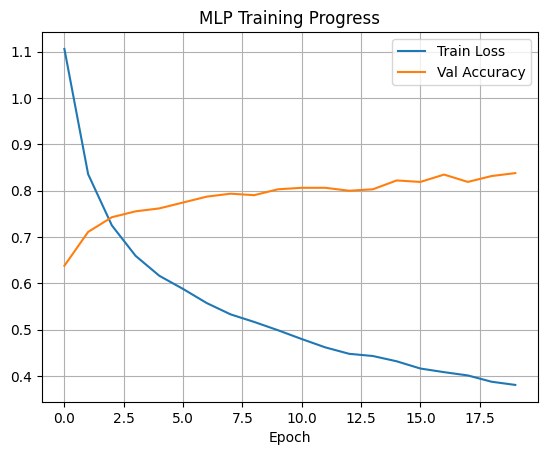

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.title("MLP Training Progress")
plt.show()

Test accuracy: 0.7968253968253968

Report:
              precision    recall  f1-score   support

      autumn       0.84      0.73      0.78        73
      spring       0.87      0.64      0.74        83
      summer       0.81      0.95      0.87        83
      winter       0.71      0.87      0.78        76

    accuracy                           0.80       315
   macro avg       0.81      0.80      0.79       315
weighted avg       0.81      0.80      0.79       315



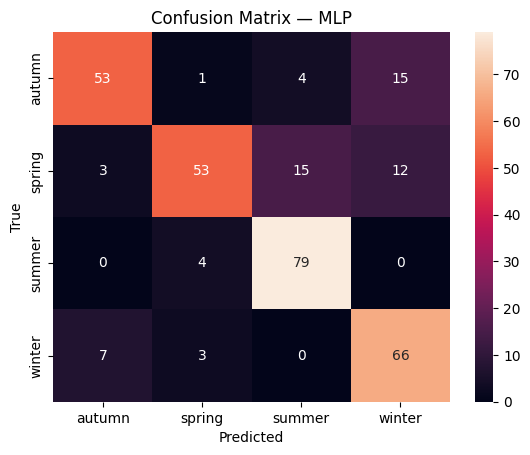

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_pred = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).argmax(1).cpu().numpy()
        y_pred.extend(preds)

print("Test accuracy:", np.mean(np.array(y_pred) == y_test))

print("\nReport:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — MLP")
plt.show()

In [ ]:
test_predictions_MLP = pd.DataFrame({
    'actual_season': le.inverse_transform(y_test),
    'predicted_season': le.inverse_transform(y_pred)
})
test_predictions_MLP

,actual_season,predicted_season
0,winter,winter
1,winter,winter
2,winter,winter
3,summer,summer
4,summer,summer
...,...,...
310,spring,spring
311,autumn,autumn
312,summer,spring
313,autumn,autumn


Summary on Task 2 - Baseline MLP
Model architecture:

Input: 72 features (flatten from 3×24)

Hidden layer: 64 neurons + ReLU

Output: 4 classes (softmax via CrossEntropyLoss)

Training:

Optimizer: Adam

LR: 0.001

Batch size: 32

Epochs: 20

Results:

Logs: loss + accuracy on validation by epochs

Error matrix and classification report

Obtained baseline accuracy on test sample



---



# Task 3

## Second Model (CNN 1D)

In [ ]:
import torch.nn as nn

class Improved1DCNN(nn.Module):
    def __init__(self, input_channels=3, output_dim=4):
        super(Improved1DCNN, self).__init__()
        # Вход: (batch_size, 3, 24)
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3)
        # -> (batch_size, 32, 22)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        # -> (batch_size, 32, 11)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3)
        # -> (batch_size, 64, 9)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        # -> (batch_size, 64, 4)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 4, 64)
        self.fc2 = nn.Linear(64, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = x.view(x.size(0), -1)  # Преобразуем в (batch_size, 64*4)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
# transform train and validation data
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

In [ ]:
model_cnn = Improved1DCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

# train
for epoch in range(1, 21):
    model_cnn.train()
    loss_total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_cnn(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        loss_total += loss.item()

    # validation
    model_cnn.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model_cnn(xb).argmax(1)
            correct += (pred == yb).sum().item()
    val_acc = correct / len(y_val)
    print(f"Epoch {epoch}: Loss = {loss_total:.3f}, Val Acc = {val_acc:.3f}")

Epoch 1: Loss = 48.189, Val Acc = 0.689
Epoch 2: Loss = 37.049, Val Acc = 0.733
Epoch 3: Loss = 30.888, Val Acc = 0.784
Epoch 4: Loss = 27.922, Val Acc = 0.797
Epoch 5: Loss = 24.177, Val Acc = 0.848
Epoch 6: Loss = 23.349, Val Acc = 0.816
Epoch 7: Loss = 22.208, Val Acc = 0.841
Epoch 8: Loss = 21.363, Val Acc = 0.822
Epoch 9: Loss = 20.319, Val Acc = 0.854
Epoch 10: Loss = 19.495, Val Acc = 0.819
Epoch 11: Loss = 18.095, Val Acc = 0.844
Epoch 12: Loss = 17.715, Val Acc = 0.848
Epoch 13: Loss = 18.498, Val Acc = 0.860
Epoch 14: Loss = 17.347, Val Acc = 0.873
Epoch 15: Loss = 16.595, Val Acc = 0.838
Epoch 16: Loss = 16.517, Val Acc = 0.841
Epoch 17: Loss = 15.058, Val Acc = 0.873
Epoch 18: Loss = 15.271, Val Acc = 0.848
Epoch 19: Loss = 16.486, Val Acc = 0.857
Epoch 20: Loss = 15.098, Val Acc = 0.848


Test Accuracy: 0.8507936507936508
              precision    recall  f1-score   support

      autumn       0.92      0.78      0.84        73
      spring       0.88      0.77      0.82        83
      summer       0.80      0.98      0.88        83
      winter       0.84      0.87      0.85        76

    accuracy                           0.85       315
   macro avg       0.86      0.85      0.85       315
weighted avg       0.86      0.85      0.85       315



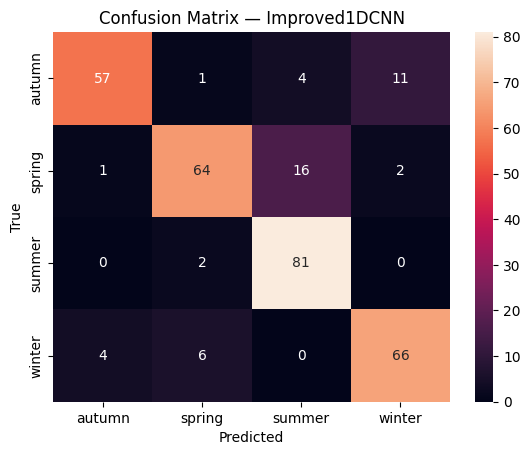

In [ ]:
model_cnn.eval()
y_pred_cnn = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds = model_cnn(xb).argmax(1).cpu().numpy()
        y_pred_cnn.extend(preds)

print("Test Accuracy:", np.mean(np.array(y_pred_cnn) == y_test))
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))

sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Improved1DCNN")
plt.show()

In [ ]:
test_predictions_CNN1D = pd.DataFrame({
    'actual_season': le.inverse_transform(y_test),
    'predicted_season': le.inverse_transform(y_pred)
})
test_predictions_CNN1D

,actual_season,predicted_season
0,winter,winter
1,winter,winter
2,winter,winter
3,summer,summer
4,summer,summer
...,...,...
310,spring,spring
311,autumn,autumn
312,summer,spring
313,autumn,autumn




---



Unlike MLP, where input data is vectorized and processed without considering the temporal structure, 1D-CNN uses convolutions along the time axis, which allows to extract local patterns and dependencies between hours in a day.

Architecture: Conv1d (3 → 32, kernel=3)

first convolution layer processes 3 input channels (load, wind, solar)
extracts local dependencies between clocks
output: (batch, 32, 22)
MaxPool1d(kernel=2)

reduces size by a factor of 2
(batch, 32, 11)
Conv1d (32 → 64, kernel=3)

even more abstract patterns
(batch, 64, 9)
MaxPool1d(kernel=2)

(batch, 64, 4)
Flatten → FC(256 → 64) → ReLU → FC(64 → 4)

final classification layers
💡 Output: 1D-CNN extracts temporal patterns that MLP ignores. It achieves better results on sequential data, especially in tasks with seasonality and clock patterns.

# Task 4

## 3 Model (CNN 2D)

In [ ]:
class ImprovedCNN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)  # (32, 12, 12)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)  # (64, 6, 6)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2)  # (128, 3, 3)

        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 4)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.fc1(x))
        return self.fc2(x)

In [ ]:
from pyts.image import GramianAngularField

gaf = GramianAngularField(image_size=24, method='summation')

def convert_dataset(X_3d):
    images = []
    for sample in X_3d:  # (3, 24)
        channels = [gaf.fit_transform(sample[i].reshape(1, -1))[0] for i in range(3)]
        img = np.stack(channels)  # (3, 24, 24)
        images.append(img)
    return np.array(images)

X_train_gaf = convert_dataset(X_train_scaled)
X_val_gaf = convert_dataset(X_val_scaled)
X_test_gaf = convert_dataset(X_test_scaled)

In [ ]:
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_gaf, dtype=torch.float32), y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_gaf, dtype=torch.float32), y_val_tensor), batch_size=32)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_gaf, dtype=torch.float32), y_test_tensor), batch_size=32)

In [ ]:
model = ImprovedCNN2D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

val_accs = []

for epoch in range(1, 21):
    model.train()
    loss_total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        loss_total += loss.item()

    # validation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    acc = correct / total
    val_accs.append(acc)
    print(f"Epoch {epoch}: Loss={loss_total:.2f}, Val Acc={acc:.3f}")

Epoch 1: Loss=52.20, Val Acc=0.667
Epoch 2: Loss=31.29, Val Acc=0.806
Epoch 3: Loss=23.56, Val Acc=0.819
Epoch 4: Loss=19.30, Val Acc=0.819
Epoch 5: Loss=12.53, Val Acc=0.806
Epoch 6: Loss=8.65, Val Acc=0.800
Epoch 7: Loss=6.65, Val Acc=0.829
Epoch 8: Loss=4.50, Val Acc=0.819
Epoch 9: Loss=3.67, Val Acc=0.829
Epoch 10: Loss=3.18, Val Acc=0.835
Epoch 11: Loss=2.14, Val Acc=0.829
Epoch 12: Loss=2.69, Val Acc=0.784
Epoch 13: Loss=4.04, Val Acc=0.775
Epoch 14: Loss=4.38, Val Acc=0.848
Epoch 15: Loss=6.96, Val Acc=0.737
Epoch 16: Loss=6.28, Val Acc=0.781
Epoch 17: Loss=3.64, Val Acc=0.825
Epoch 18: Loss=1.22, Val Acc=0.829
Epoch 19: Loss=0.42, Val Acc=0.832
Epoch 20: Loss=0.12, Val Acc=0.835


Test accuracy: 0.8253968253968254

Report:
              precision    recall  f1-score   support

      autumn       0.87      0.75      0.81        73
      spring       0.81      0.70      0.75        83
      summer       0.79      0.92      0.85        83
      winter       0.85      0.93      0.89        76

    accuracy                           0.83       315
   macro avg       0.83      0.83      0.82       315
weighted avg       0.83      0.83      0.82       315



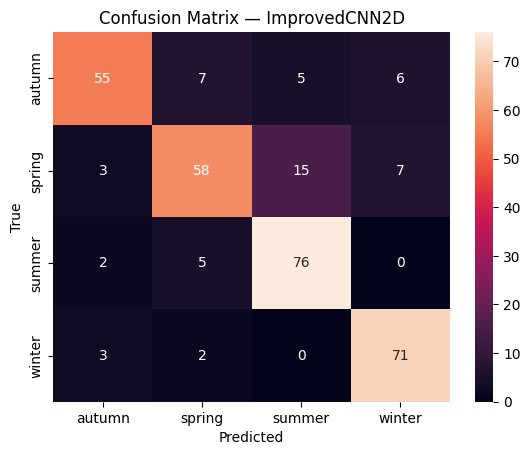

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_pred = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).argmax(1).cpu().numpy()
        y_pred.extend(preds)

print("Test accuracy:", np.mean(np.array(y_pred) == y_test))

print("\nReport:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — ImprovedCNN2D")
plt.show()

In [ ]:
test_predictions_CNN2D_over = pd.DataFrame({
    'actual_season': le.inverse_transform(y_test),
    'predicted_season': le.inverse_transform(y_pred)
})
test_predictions_CNN2D_over

,actual_season,predicted_season
0,winter,winter
1,winter,winter
2,winter,winter
3,summer,summer
4,summer,summer
...,...,...
310,spring,spring
311,autumn,autumn
312,summer,summer
313,autumn,autumn


In [ ]:
class SimplifiedCNN2D_v2(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout2d(0.1)
        self.pool1 = nn.MaxPool2d(2)  # (16, 12, 12)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout2d(0.2)
        self.pool2 = nn.MaxPool2d(2)  # (32, 6, 6)

        self.dropout_fc = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 6 * 6, 64)
        self.fc2 = nn.Linear(64, 4)

    def forward(self, x):
        x = self.pool1(self.drop1(self.relu1(self.bn1(self.conv1(x)))))
        x = self.pool2(self.drop2(self.relu2(self.bn2(self.conv2(x)))))
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(self.fc1(x))
        return self.fc2(x)

In [ ]:
model = SimplifiedCNN2D_v2().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

val_accs = []

for epoch in range(1, 21):
    model.train()
    loss_total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        loss_total += loss.item()

    # validation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    acc = correct / total
    val_accs.append(acc)
    print(f"Epoch {epoch}: Loss={loss_total:.2f}, Val Acc={acc:.3f}")

Epoch 1: Loss=55.07, Val Acc=0.654
Epoch 2: Loss=40.26, Val Acc=0.743
Epoch 3: Loss=35.49, Val Acc=0.756
Epoch 4: Loss=28.94, Val Acc=0.778
Epoch 5: Loss=26.49, Val Acc=0.762
Epoch 6: Loss=27.31, Val Acc=0.752
Epoch 7: Loss=23.90, Val Acc=0.787
Epoch 8: Loss=20.11, Val Acc=0.800
Epoch 9: Loss=19.54, Val Acc=0.825
Epoch 10: Loss=19.29, Val Acc=0.803
Epoch 11: Loss=17.98, Val Acc=0.803
Epoch 12: Loss=18.05, Val Acc=0.819
Epoch 13: Loss=17.26, Val Acc=0.819
Epoch 14: Loss=14.08, Val Acc=0.816
Epoch 15: Loss=13.12, Val Acc=0.841
Epoch 16: Loss=14.75, Val Acc=0.810
Epoch 17: Loss=13.62, Val Acc=0.825
Epoch 18: Loss=11.79, Val Acc=0.819
Epoch 19: Loss=10.83, Val Acc=0.825
Epoch 20: Loss=9.82, Val Acc=0.810


Test accuracy: 0.8158730158730159

Report:
              precision    recall  f1-score   support

      autumn       0.80      0.81      0.80        73
      spring       0.75      0.77      0.76        83
      summer       0.84      0.78      0.81        83
      winter       0.87      0.91      0.89        76

    accuracy                           0.82       315
   macro avg       0.82      0.82      0.82       315
weighted avg       0.82      0.82      0.82       315



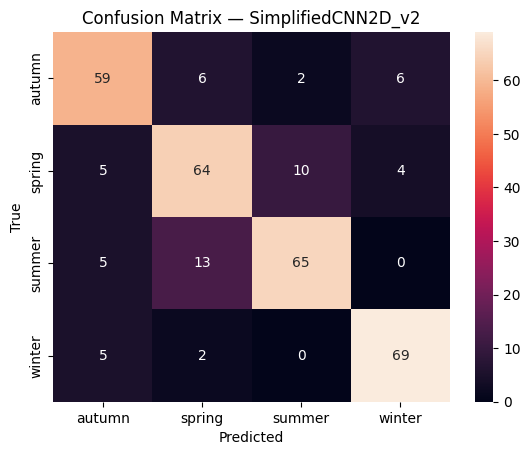

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_pred = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).argmax(1).cpu().numpy()
        y_pred.extend(preds)

print("Test accuracy:", np.mean(np.array(y_pred) == y_test))

print("\nReport:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — SimplifiedCNN2D_v2")
plt.show()

In [ ]:
test_predictions_CNN2D_simple = pd.DataFrame({
    'actual_season': le.inverse_transform(y_test),
    'predicted_season': le.inverse_transform(y_pred)
})
test_predictions_CNN2D_simple

,actual_season,predicted_season
0,winter,winter
1,winter,winter
2,winter,winter
3,summer,summer
4,summer,spring
...,...,...
310,spring,spring
311,autumn,autumn
312,summer,spring
313,autumn,autumn


The Gramian Angular Field (GAF) method from the pyts library was used to transform time series into images. It translates a one-dimensional time series into a square symmetric matrix that preserves:

temporal dependencies (hourly structure)

amplitude patterns

seasonality patterns - as textures and patterns

For each day (24 hours × 3 features), 3 GAF maps of size 24×24 were obtained. These 3 channels form a “color image” in (3, 24, 24) format, similar to an RGB image.
